# Introducción a las RRNN con Keras
#### UD4. Redes Neuronales
#### MP. Sistemas de Aprendizaxe Automáticos
#### IES de Teis (Vigo), Vanesa Resúa Eiras, Cristina Gómez Alonso

Toma como base el siguiente [tutorial oficial de Keras](https://keras.io/examples/vision/mnist_convnet/) de François Chollet y crea una red neuronal simple en lugar de una convolucional.

In [ ]:
import numpy as np
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
import matplotlib.pyplot as plt
from matplotlib import image
import tensorflow as tf
%matplotlib inline

I0000 00:00:1775547487.639451   78965 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775547487.677700   78965 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775547488.679242   78965 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# 1. Importación dataset MNIST

1.1. Carga el dataset de ejemplo MNIST separando el conjunto de entrenamiento del de pruebas.

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# 2. EDA & Visual EDA

2.1. Comprueba la forma y dimensiones de las imágenes importadas.

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


osea tendria 6000 formas de escribir 5 por ejemplo

2.2. Calcula el ancho, alto y total de pixeles de cada imagen.

In [ ]:
print('alto:' + str(len(X_train[0])))
print('ancho:' + str(len(X_train[0][0])))

alto:28
ancho:28


2.3. Muestra algunas de las imágenes cargadas y comprueba que se ven correctamente.
Para mostrar varias, puedes usar:
* plt.subplot(x, y, i) y
* plt.imshow()

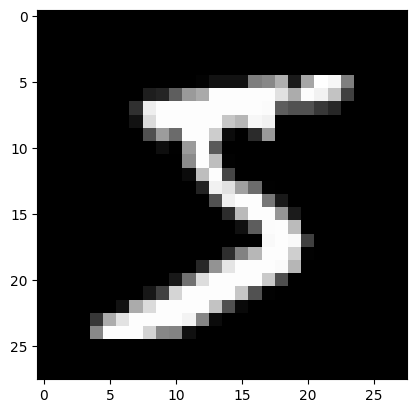

In [ ]:
plt.imshow(X_train[0].reshape(28, 28), cmap='gray')

# 3. Preparación del dataset para la Red Neuronal

3.1. Convierte los datos a coma flotante ‘float32’.

In [ ]:
float_X_train = X_train.astype("float32")
float_X_test = X_test.astype("float32")
float_y_train = y_train.astype("float32")
float_y_test = y_test.astype("float32")

3.2. Transforma las imágenes para que todos sus píxeles se encuentren en `[0, 1]`

In [ ]:
normalized_X_train = float_X_train / 255
normalized_X_test = float_X_test / 255

3.3. Redimensiona/reacondiciona las dimensiones de las imágenes para que tengan las dimensiones que la red neuronal puede procesar.

estamos haciendo un aplanado, porque la red neuronal es plana es decir convertir de dos dimensiones a una dimensión 

In [ ]:
input_array_size = len(normalized_X_train[0]) * len(normalized_X_train[0][0]) # Tamaño del array al aplanar cada matriz de píxeles.
print(input_array_size)

final_X_train = normalized_X_train.reshape(normalized_X_train.shape[0],input_array_size)
print(final_X_train.shape)
final_X_test = X_test.reshape(X_test.shape[0],input_array_size)
print(final_X_test.shape)

784
(60000, 784)
(10000, 784)


Porque vamos a usar una red neuronal con capas densas (Dense). Las capas densas clásicas esperan recibir la información en forma de un vector de una sola dimensión (una fila larga de números). No saben interpretar una matriz en 2D (una cuadrícula). Por eso transformamos las imágenes de 28x28 en filas planas de 784 píxeles

3.4. Calcula el número de clases de que dispone el conjunto de datos.

In [ ]:
labels = np.unique(float_y_train)
labels

array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.], dtype=float32)

3.5. Convierte a categóricas las etiquetas del conjunto de entrenamiento (y_train) y del conjunto de test (y_test).

In [ ]:
final_y_train = tf.keras.utils.to_categorical(float_y_train, len(labels))
final_y_test = tf.keras.utils.to_categorical(float_y_test, len(labels))
print(final_y_train.shape)
print(final_y_test.shape)

(60000, 10)
(10000, 10)


# 4. Creación de la Red Neuronal

In [ ]:
model = Sequential()

4.2. Inserta una primera capa con las siguientes características:
* Que contenga 1000 neuronas
* Que acepte una entrada igual al número de píxeles de las imágenes que va a procesar
* Que use `Relu` como función de activación

In [ ]:
model.add(Dense(1000, input_dim=input_array_size, activation='relu'))

/media/a22nicolesdc/DIURNOEXTRA/miniconda3/envs/ML/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1775547947.257056   78965 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


4.3. Construye la capa de salida. Usa `softmax` como función de activación

Como estamos clasificando dígitos del 0 al 9. Hay 10 clases posibles en total. Cada neurona de la capa de salida representa la probabilidad de que la imagen pertenezca a una de esas clases.

1. La Capa Oculta (1000 neuronas)Esta es la primera capa que pusiste después de aplanar la imagen.Entradas: 784 (los píxeles de cada imagen de 28x28).Neuronas: 1000.Cálculo de Pesos: Cada una de las 1000 neuronas se conecta a cada uno de los 784 píxeles. Por tanto: $784 \times 1000 = 784,000$ pesos.Cálculo de Sesgos: 1000 (uno por neurona).Total Capa 1: $784,000 + 1000 =$ 785,000 parámetros.

2. La Capa de Salida (10 neuronas)Esta es la capa final que te da la probabilidad de los números del 0 al 9.Entradas: 1000 (ahora las entradas ya no son los píxeles, sino los resultados que escupen las 1000 neuronas de la capa anterior).Neuronas: 10 (calculadas con el famoso len(labels)).Cálculo de Pesos: $1000 \times 10 = 10,000$ pesos.Cálculo de Sesgos: 10.Total Capa 2: $10,000 + 10 =$ 10,010 parámetros.Total de tu Red NeuronalSi sumas ambas capas ($785,000 + 10,010$), tu modelo tiene un total de 795,010 parámetros entrenables.

In [ ]:
model.add(Dense(len(labels), activation='softmax'))
# se le pasa el lens porque asi si cambia el numero de salida que tengo de numero se cambia auotmatic
# la salida en este caso es de 10 porque son los numeros del 0 al 9 
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1000)           │       785,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 795,010 (3.03 MB)

 Trainable params: 795,010 (3.03 MB)

 Non-trainable params: 0 (0.00 B)

None


# 5. Entrenamiento
5.1. Compila el modelo creado:
* Usa categorical crossentropy como función de pérdida
* Usa `adam` como optimizador
* Usa la precisión como métrica

In [ ]:
model.compile(loss='categorical_crossentropy',
            optimizer='adam',
            metrics=['accuracy'])

5.2. Comprueba la configuración de la RN antes creada

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1000)           │       785,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 795,010 (3.03 MB)

 Trainable params: 795,010 (3.03 MB)

 Non-trainable params: 0 (0.00 B)

La característica principal de una capa Densa es que exige que absolutamente todos los datos de entrada se conecten mediante un cable (un peso) con absolutamente todas las neuronas de la capa. Como nuestra imagen tiene muchos píxeles (784) y le hemos dicho a Keras que ponga una barbaridad de neuronas de golpe (1000), el número de conexiones explota matemáticamente.

Esos 795,010 parámetros son, básicamente, casi 800.000 "ruedas de volumen" que el optimizador Adam tiene que estar ajustando milimétricamente arriba y abajo en cada época para conseguir que la red aprenda a distinguir la curva de un "8" de la curva de un "3". ¡Por eso el entrenamiento con tamaños de batch muy pequeños tarda tanto!

5.3. Entrena el modelo anterior usando la información del conjunto de datos de entrenamiento y el de test para validar la evolución y calidad del aprendizaje. Usa 5 épocas y un tamaño de batch de 1024 en cada pasada. Indica verbose 1, para que muestre la información del proceso.

validation_data -> Sirve para evaluar cómo de bien generaliza la red. Durante el entrenamiento, nos mostrará el accuracy (lo bien que se le dan los datos que ya ha visto) y el val_accuracy (lo bien que clasifica los datos de test que son completamente nuevos). Si vemos que acierta mucho en entrenamiento pero falla en validación, sabemos que hay un problema de sobreajuste (overfitting)

In [ ]:
print("Comenzando el entrenamiento...")

history = model.fit(final_X_train, final_y_train,
                    batch_size=1024,
                    epochs=5,
                    verbose=1,
                    validation_data=(final_X_test, final_y_test))

print("¡Entrenamiento terminado!")

Comenzando el entrenamiento...
Epoch 1/5
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8663 - loss: 0.4835 - val_accuracy: 0.9359 - val_loss: 29.3267
Epoch 2/5
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9449 - loss: 0.1968 - val_accuracy: 0.9532 - val_loss: 19.6854
Epoch 3/5
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9610 - loss: 0.1409 - val_accuracy: 0.9608 - val_loss: 16.7579
Epoch 4/5
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9703 - loss: 0.1069 - val_accuracy: 0.9684 - val_loss: 13.8866
Epoch 5/5
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9767 - loss: 0.0858 - val_accuracy: 0.9708 - val_loss: 12.5585
¡Entrenamiento terminado!


# 6. Visualización

6.1. Muestra gráficamente la evolución de la precisión del modelo.

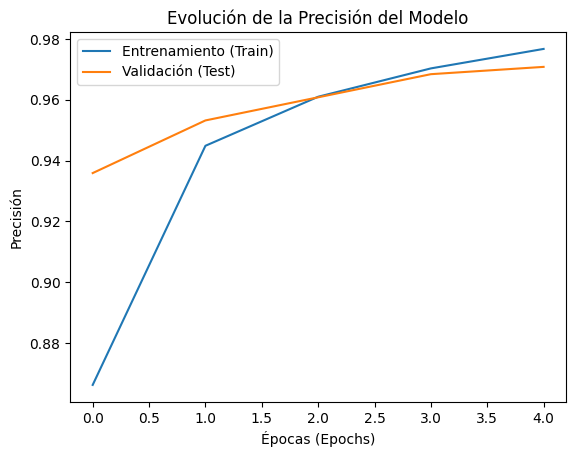

In [ ]:
#la línea de la precisión en los datos de entrenamiento
plt.plot(history.history['accuracy'], label='Entrenamiento (Train)')

#la línea de la precisión en los datos de validación/test
plt.plot(history.history['val_accuracy'], label='Validación (Test)')

plt.title('Evolución de la Precisión del Modelo')
plt.ylabel('Precisión')
plt.xlabel('Épocas (Epochs)')
plt.legend()

plt.show()

En la gráfica de precisión, ambas líneas deberían subir rápidamente al principio y luego estabilizarse cerca del 1.5

6.2. Muestra gráficamente la evolución de la función de pérdida.

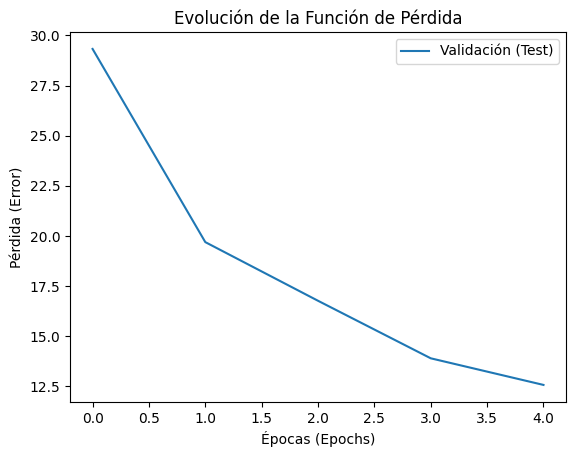

In [ ]:
#la línea de los errores en entrenamiento

#la línea de los errores en validación/test
plt.plot(history.history['val_loss'], label='Validación (Test)')

plt.title('Evolución de la Función de Pérdida')
plt.ylabel('Pérdida (Error)')
plt.xlabel('Épocas (Epochs)')
plt.legend()

plt.show()

En la gráfica de pérdida, ambas líneas deberían bajar hacia el 0. Además, las líneas de entrenamiento y validación deberían ir muy juntas

El overfitting ocurre cuando la red empieza a memorizar las imágenes de entrenamiento en lugar de aprender patrones generales. En las gráficas lo veríamos si la línea de entrenamiento sigue mejorando (precisión sube, pérdida baja), pero la línea de validación se estanca o empieza a empeorar (la pérdida sube). Se vería como si las dos líneas se separaran formando una boca de cocodrilo xd

# 7. Re-entrenamiento con nuevos parámetros


7.1. Entrena el modelo usando ahora los parámetros siguientes
* validation_split = 0.1, epochs=15, batch_size=4
* validation_split = 0.1, epochs=50, batch_size=1024

In [ ]:
# para no repetir codigo de crear modelo y llamo a la funcion y ya 
def crear_modelo():
    modelo = Sequential()
    modelo.add(Dense(1000, input_dim=input_array_size, activation='relu'))
    modelo.add(Dense(len(labels), activation='softmax'))
    modelo.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return modelo

In [ ]:

print("--- Entrenando Modelo 1 (Batch: 4, Epochs: 15) ---")
modelo_1 = crear_modelo()
# Fíjate en validation_split=0.1. Ya no usamos (final_X_test, final_y_test)
historia_1 = modelo_1.fit(final_X_train, final_y_train, validation_split=0.1, epochs=15, batch_size=4, verbose=1)

print("\n--- Entrenando Modelo 2 (Batch: 1024, Epochs: 50) ---")
modelo_2 = crear_modelo()
historia_2 = modelo_2.fit(final_X_train, final_y_train, validation_split=0.1, epochs=50, batch_size=1024, verbose=1)

--- Entrenando Modelo 1 (Batch: 4, Epochs: 15) ---
Epoch 1/15
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 61s 4ms/step - accuracy: 0.9403 - loss: 0.1965 - val_accuracy: 0.9672 - val_loss: 0.1138
Epoch 2/15
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 60s 4ms/step - accuracy: 0.9707 - loss: 0.1011 - val_accuracy: 0.9733 - val_loss: 0.1078
Epoch 3/15
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 60s 4ms/step - accuracy: 0.9785 - loss: 0.0782 - val_accuracy: 0.9722 - val_loss: 0.1395
Epoch 4/15
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 61s 4ms/step - accuracy: 0.9825 - loss: 0.0656 - val_accuracy: 0.9758 - val_loss: 0.1367
Epoch 5/15
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 61s 4ms/step - accuracy: 0.9864 - loss: 0.0575 - val_accuracy: 0.9785 - val_loss: 0.1318
Epoch 6/15
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 61s 5ms/step - accuracy: 0.9884 - loss: 0.0469 - val_accuracy: 0.9785 - val_loss: 0.1434
Epoch 7/15
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 61s 4ms/step - accuracy: 0.9890 - loss: 0.0479 - val_accuracy: 0.9787 - val_loss: 0.1478
Epoch 8/15
13500/1

validation_split=0.1? En lugar de darle el conjunto de Test entero como hicimos antes, esta instrucción le dice a la red: "Coge el 10% de tus propios apuntes de entrenamiento, escóndelos, y úsalos para hacerte un simulacro de examen en cada época, para lo del overfitting

7.2. Muestra gráficamente la evolución de la precisión y función de pérdida del modelo recien entrenado. Extrae conclusiones.

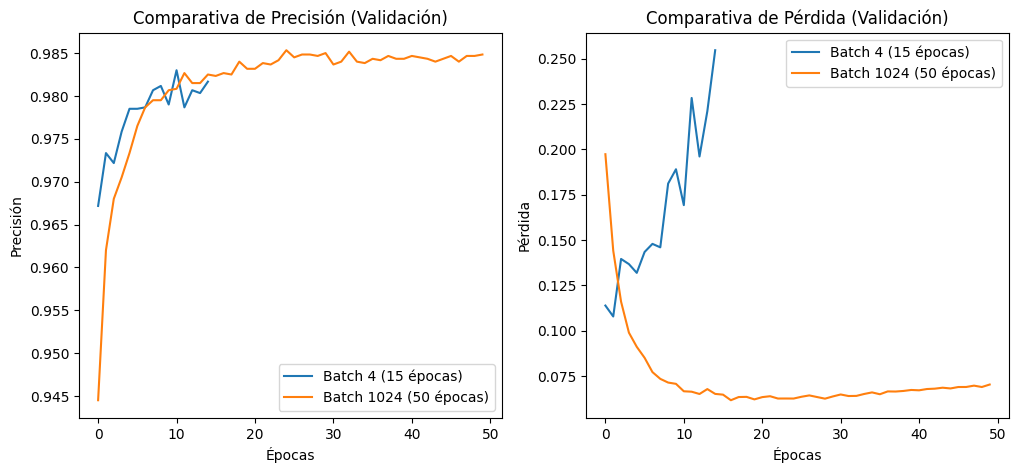

In [ ]:
plt.figure(figsize=(12, 5))

# Gráfica 1: Precisión
plt.subplot(1, 2, 1)
plt.plot(historia_1.history['val_accuracy'], label='Batch 4 (15 épocas)')
plt.plot(historia_2.history['val_accuracy'], label='Batch 1024 (50 épocas)')
plt.title('Comparativa de Precisión (Validación)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Gráfica 2: Pérdida (Error)
plt.subplot(1, 2, 2)
plt.plot(historia_1.history['val_loss'], label='Batch 4 (15 épocas)')
plt.plot(historia_2.history['val_loss'], label='Batch 1024 (50 épocas)')
plt.title('Comparativa de Pérdida (Validación)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.show()

# Opcional: ConvNet
Revisa el tutorial y cambia tu compilación para crear un red neuronal convolucional.


In [ ]:
from keras.layers import Conv2D, MaxPooling2D, Flatten

# 1. PREPARACIÓN DE DATOS
# Las ConvNets necesitan saber los canales de color. Como es blanco y negro, el canal es 1.
# Re-acondicionamos las imágenes normalizadas para que tengan la forma (28, 28, 1)
X_train_cnn = normalized_X_train.reshape(-1, 28, 28, 1)
X_test_cnn = normalized_X_test.reshape(-1, 28, 28, 1)

# 2. CREACIÓN DEL MODELO CONVOLUCIONAL
modelo_cnn = Sequential()

# Añadimos la capa Convolucional (pasa 32 "lupas" de 3x3 píxeles buscando patrones)
modelo_cnn.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

# Añadimos una capa de Pooling (reduce el tamaño de la imagen a la mitad, quedándose con lo más importante)
modelo_cnn.add(MaxPooling2D(pool_size=(2, 2)))

# Ahora que ya sacamos las características espaciales, APLANAMOS el resultado
modelo_cnn.add(Flatten())

# Y se lo pasamos a la capa final de siempre (10 neuronas, una por número)
modelo_cnn.add(Dense(len(labels), activation='softmax'))

# 3. COMPILACIÓN Y ENTRENAMIENTO
modelo_cnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("Entrenando la ConvNet... (Puede tardar un poquito más)")
historia_cnn = modelo_cnn.fit(X_train_cnn, final_y_train, validation_split=0.1, epochs=5, batch_size=128, verbose=1)

Entrenando la ConvNet... (Puede tardar un poquito más)
Epoch 1/5


/media/a22nicolesdc/DIURNOEXTRA/miniconda3/envs/ML/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8935 - loss: 0.3931 - val_accuracy: 0.9595 - val_loss: 0.1533
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9570 - loss: 0.1514 - val_accuracy: 0.9740 - val_loss: 0.1000
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9714 - loss: 0.1023 - val_accuracy: 0.9775 - val_loss: 0.0823
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9769 - loss: 0.0808 - val_accuracy: 0.9803 - val_loss: 0.0736
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9809 - loss: 0.0681 - val_accuracy: 0.9843 - val_loss: 0.0662
